<a href="https://colab.research.google.com/github/njwbilll/Tugas-5_Grokking-Deep-Learning-MANNING_Najwa-Bilqis-Al-Khalidah/blob/main/06_Building_your_first_deep_neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Chapter 6: Building Your First Deep Neural Network: Introduction to Backpropagation

**Referensi Utama:** Grokking Deep Learning, Andrew W. Trask

## Ringkasan Chapter

Bab 6 merupakan salah satu bab terpenting dalam buku Grokking Deep Learning karena untuk pertama kalinya pembaca membangun deep neural network yang sesungguhnya. Pada bab ini diperkenalkan konsep backpropagation, hidden layer, korelasi langsung dan tidak langsung, batch gradient descent, serta proses pembelajaran neural network menggunakan operasi matriks.

Topik utama yang dibahas:

1. The Streetlight Problem
2. Persiapan Dataset
3. Matriks dan Hubungan Matriks
4. Membangun Neural Network Dua Layer
5. Batch Learning
6. Full Batch dan Stochastic Gradient Descent
7. Correlation Learning
8. Overfitting
9. Indirect Correlation
10. Backpropagation
11. Deep Neural Network Pertama
12. Implementasi Lengkap Menggunakan NumPy

Notebook ini mereproduksi ide inti dan kode penting dari Chapter 6 dengan penjelasan teori yang diperluas menggunakan bahasa Indonesia.



## Setup Environment


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(1)

print("Environment siap digunakan")


Environment siap digunakan



## 1. The Streetlight Problem

### Penjelasan Teori

Streetlight problem merupakan contoh klasik yang digunakan Andrew Trask untuk menjelaskan bagaimana neural network belajar dari data.

Misalkan terdapat lampu lalu lintas dengan tiga lampu:

1. Merah
2. Kuning
3. Hijau

Tujuan model adalah menentukan apakah mobil harus berjalan atau berhenti.

Representasi data:

Merah = [1,0,0]

Kuning = [0,1,0]

Hijau = [0,0,1]

Target:

Berhenti = 0

Jalan = 1

Contoh ini sangat penting karena memperlihatkan bagaimana bobot dapat mempelajari hubungan antara fitur dan target.


In [2]:

streetlights = np.array([
    [1,0,0],
    [0,1,0],
    [0,0,1],
    [1,0,0],
    [0,1,0],
    [0,0,1]
])

walk_vs_stop = np.array([0,1,1,0,1,1])

print(streetlights)
print(walk_vs_stop)


[[1 0 0]
 [0 1 0]
 [0 0 1]
 [1 0 0]
 [0 1 0]
 [0 0 1]]
[0 1 1 0 1 1]



## 2. Hubungan Matriks pada Neural Network

### Penjelasan Teori

Mulai bab ini neural network tidak lagi hanya menggunakan satu bobot.

Kita menggunakan matriks.

Misalkan:

Input Layer = 3 neuron

Hidden Layer = 4 neuron

Output Layer = 1 neuron

Maka:

Weight Input Hidden memiliki ukuran 3 x 4

Weight Hidden Output memiliki ukuran 4 x 1

Perkalian matriks memungkinkan banyak neuron diproses secara paralel.


In [3]:

input_layer = 3
hidden_layer = 4
output_layer = 1

weights_0_1 = np.random.rand(input_layer, hidden_layer)
weights_1_2 = np.random.rand(hidden_layer, output_layer)

print("Shape W0_1:", weights_0_1.shape)
print("Shape W1_2:", weights_1_2.shape)


Shape W0_1: (3, 4)
Shape W1_2: (4, 1)



## 3. Forward Propagation

### Penjelasan Teori

Forward propagation adalah proses mengalirkan informasi dari input menuju output.

Langkah:

Input

→ Hidden Layer

→ Output Layer

Belum ada proses belajar pada tahap ini.

Model hanya melakukan prediksi.


In [4]:

input_data = streetlights[0]

hidden = np.dot(input_data, weights_0_1)

prediction = np.dot(hidden, weights_1_2)

print("Hidden Layer")
print(hidden)

print("\nPrediction")
print(prediction)


Hidden Layer
[4.17022005e-01 7.20324493e-01 1.14374817e-04 3.02332573e-01]

Prediction
[0.92049788]



## 4. Fungsi Aktivasi ReLU

### Penjelasan Teori

Pada Chapter 6 diperkenalkan penggunaan non linearity.

ReLU didefinisikan sebagai:

ReLU(x) = max(0,x)

Keuntungan:

1. Sederhana
2. Cepat dihitung
3. Mengurangi masalah vanishing gradient
4. Menjadi standar pada banyak arsitektur modern


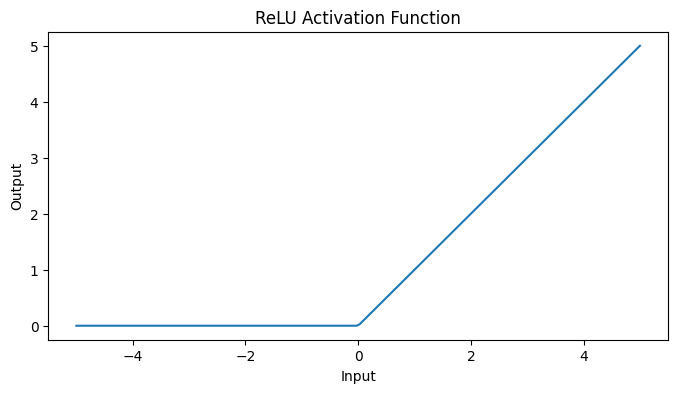

In [5]:

def relu(x):
    return (x > 0) * x

x = np.linspace(-5,5,200)

plt.figure(figsize=(8,4))
plt.plot(x,relu(x))
plt.title("ReLU Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.show()



## 5. Deep Neural Network Pertama

### Penjelasan Teori

Inilah inti Chapter 6.

Arsitektur:

Input Layer

3 neuron

Hidden Layer

4 neuron

Output Layer

1 neuron

Hidden layer memungkinkan model mempelajari pola yang lebih kompleks dibanding model linear pada chapter sebelumnya.


In [6]:

alpha = 0.2

hidden_size = 4

weights_0_1 = 2 * np.random.random((3, hidden_size)) - 1
weights_1_2 = 2 * np.random.random((hidden_size, 1)) - 1

for iteration in range(60):

    layer_0 = streetlights

    layer_1 = relu(np.dot(layer_0, weights_0_1))

    layer_2 = np.dot(layer_1, weights_1_2)

    error = layer_2.flatten() - walk_vs_stop

    mse = np.mean(error ** 2)

    if iteration % 10 == 0:
        print("Iteration:", iteration, "MSE:", round(mse,6))

    layer_2_delta = error.reshape(-1,1)

    layer_1_delta = np.dot(layer_2_delta, weights_1_2.T)
    layer_1_delta = layer_1_delta * (layer_1 > 0)

    weights_1_2 -= alpha * np.dot(layer_1.T, layer_2_delta)
    weights_0_1 -= alpha * np.dot(layer_0.T, layer_1_delta)


Iteration: 0 MSE: 0.460058
Iteration: 10 MSE: 1e-06
Iteration: 20 MSE: 0.0
Iteration: 30 MSE: 0.0
Iteration: 40 MSE: 0.0
Iteration: 50 MSE: 0.0



## 6. Memahami Backpropagation

### Penjelasan Teori

Backpropagation adalah algoritma yang memungkinkan neural network mengetahui kontribusi setiap bobot terhadap kesalahan akhir.

Alur proses:

Forward Propagation

Hitung Error

Hitung Gradient

Sebarkan Error ke Layer Sebelumnya

Update Bobot

Konsep utama:

Error pada output tidak langsung memberi tahu bobot mana yang salah.

Backpropagation bertugas mengatribusikan kesalahan tersebut ke seluruh jaringan.


In [7]:

layer_0 = streetlights

layer_1 = relu(np.dot(layer_0, weights_0_1))

layer_2 = np.dot(layer_1, weights_1_2)

print("Output setelah training")
print(np.round(layer_2.flatten(),3))


Output setelah training
[0. 1. 1. 0. 1. 1.]



## 7. Batch Gradient Descent

### Penjelasan Teori

Chapter 6 menjelaskan perbedaan tiga pendekatan training.

### Stochastic Gradient Descent

Satu sampel setiap update.

### Batch Gradient Descent

Seluruh dataset digunakan sekaligus.

### Mini Batch Gradient Descent

Sebagian dataset digunakan pada setiap iterasi.

Pada notebook ini digunakan pendekatan batch karena seluruh data diproses bersamaan.


In [8]:

samples = len(streetlights)

print("Jumlah sampel:", samples)

for i in range(samples):
    print("Sample", i + 1, streetlights[i], "Target:", walk_vs_stop[i])


Jumlah sampel: 6
Sample 1 [1 0 0] Target: 0
Sample 2 [0 1 0] Target: 1
Sample 3 [0 0 1] Target: 1
Sample 4 [1 0 0] Target: 0
Sample 5 [0 1 0] Target: 1
Sample 6 [0 0 1] Target: 1



## 8. Correlation Learning

### Penjelasan Teori

Andrew Trask menekankan bahwa neural network pada dasarnya belajar korelasi.

Jika suatu fitur berkorelasi positif terhadap target maka bobot cenderung meningkat.

Jika berkorelasi negatif maka bobot akan bergerak ke arah berlawanan.

Jika tidak berkorelasi maka kontribusinya akan kecil.

Inilah alasan mengapa neural network mampu menemukan pola yang tidak langsung terlihat oleh manusia.


In [9]:

df = pd.DataFrame(streetlights, columns=["Red","Yellow","Green"])
df["Target"] = walk_vs_stop

print(df.corr())


        Red  Yellow  Green  Target
Red     1.0    -0.5   -0.5    -1.0
Yellow -0.5     1.0   -0.5     0.5
Green  -0.5    -0.5    1.0     0.5
Target -1.0     0.5    0.5     1.0



## 9. Overfitting

### Penjelasan Teori

Overfitting terjadi ketika model terlalu menghafal data training.

Gejalanya:

1. Akurasi training sangat tinggi
2. Akurasi data baru rendah
3. Generalisasi buruk

Pada Chapter 6 konsep ini mulai diperkenalkan sebagai edge case penting dalam deep learning.



## 10. Mengapa Hidden Layer Penting

### Penjelasan Teori

Pada chapter sebelumnya jaringan hanya memiliki hubungan langsung:

Input → Output

Pada Chapter 6:

Input → Hidden → Output

Hidden layer memungkinkan pembelajaran korelasi tidak langsung.

Contoh:

Piksel gambar secara individual mungkin tidak menunjukkan keberadaan kucing.

Namun kombinasi banyak piksel dapat membentuk pola telinga, mata, dan wajah.

Hidden layer membantu menemukan representasi tersebut.



## 11. Ringkasan Teori Chapter 6

Konsep penting yang harus dipahami:

1. Neural network dapat direpresentasikan menggunakan matriks.
2. Hidden layer memungkinkan pembelajaran pola yang lebih kompleks.
3. Forward propagation menghasilkan prediksi.
4. Error mengukur kualitas prediksi.
5. Backpropagation menyebarkan kesalahan ke seluruh jaringan.
6. Gradient digunakan untuk memperbarui bobot.
7. ReLU memperkenalkan non linearity.
8. Batch learning memproses seluruh dataset sekaligus.
9. Neural network belajar korelasi antar variabel.
10. Deep network mampu mempelajari hubungan tidak langsung.



## Kesimpulan

Chapter 6 merupakan transisi dari neural network sederhana menuju deep neural network. Pada bab ini diperkenalkan hidden layer, operasi matriks, ReLU, batch gradient descent, dan terutama backpropagation. Seluruh konsep tersebut menjadi fondasi bagi chapter chapter berikutnya seperti regularization, activation function, convolutional neural network, NLP, RNN, dan federated learning.

Memahami Chapter 6 dengan baik sangat penting karena hampir seluruh algoritma deep learning modern tetap menggunakan prinsip dasar forward propagation dan backpropagation yang sama.
